# 🦕 JURASSIC PARK: Pipelines de ML con Velocirráptores
## De la Experimentación al Sistema en Producción

---

> *"La vida... se abre camino."* — Dr. Ian Malcolm

Bienvenido de nuevo al Departamento Data Analyst & IA de **InGen Corporation**.

En este notebook aprenderás a construir un sistema **escalable, reproducible y listo para producción**
usando **Pipelines de Machine Learning**.

---

### 🗺️ Mapa del recorrido

| Paso | Contenido | Objetivo |
|---|---|---|
| 0 | Setup | Imports organizados para producción |
| 1 | Dataset | Datos de comportamiento raptor |
| 2 | EDA | Exploración antes de modelar |
| 3 | ¿Qué es un Pipeline? | Concepto clave |
| 4 | Data Leakage | El error más peligroso en ML |
| 5 | Construir Pipeline | Scikit-learn Pipeline API |
| 6 | Validación Cruzada | Evaluación robusta |
| 7 | GridSearchCV + Pipeline | Optimización automática |
| 8 | Evaluación Final | Métricas en test set |
| 9 | Serialización | Guardar y versionar modelos |
| 10 | Producción | Usar el modelo en el mundo real |


---
## 📦 PASO 0: Setup — Imports organizados para producción

En un proyecto de producción, los imports se organizan en bloques lógicos.
Esto facilita el mantenimiento y deja claro qué usa cada librería.

In [7]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ── Manipulación de datos ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: Pipeline y Preprocesamiento ─────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Scikit-learn: División de datos ──────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# ── Scikit-learn: Modelos ─────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: Métricas ────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ── Serialización de modelos ──────────────────────────────────────────────────
import joblib

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print("✅ Setup completado. InGen ML System v1.0 iniciado.")
print("🦖 Departamento de Data Analyst & IA — Proyecto Raptor-Pipeline")

✅ Setup completado. InGen ML System v1.0 iniciado.
🦖 Departamento de Data Analyst & IA — Proyecto Raptor-Pipeline


---
## 🔍 PASO 1: El Dataset — Observaciones de Velocirráptores

Creamos un data set sintético con variables de distintos tipos (numéricas y categóricas) para practicar el preprocesamiento
de múltiples tipos de datos dentro del pipeline.

| Variable | Descripción | Tipo |
|---|---|---|
| `hambre` | Nivel de hambre (0-10) | Numérica |
| `distancia_presa` | Distancia a la presa en metros | Numérica |
| `temperatura` | Temperatura ambiental (°C) | Numérica |
| `vocalizaciones` | Sonidos emitidos (por minuto) | Numérica |
| `en_manada` | ¿Está en grupo? (1=Sí, 0=No) | Binaria |
| `especie` | Subespecie del raptor | **Categórica** (nueva) |
| `ataca` | ⚠️ Variable objetivo | Binaria |

In [2]:
np.random.seed(SEED)
n = 500

hambre          = np.random.randint(1, 11, n)
distancia_presa = np.random.randint(1, 50, n)
temperatura     = np.round(np.random.uniform(20, 40, n), 1)
en_manada       = np.random.randint(0, 2, n)
vocalizaciones  = np.random.randint(0, 20, n)

# Variable categórica: subespecie del raptor
especies = np.random.choice(['velociraptor', 'utahraptor', 'deinonychus'], n,
                             p=[0.5, 0.3, 0.2])

# Regla de ataque (utahraptor es más agresivo)
bonus_especie = np.where(especies == 'utahraptor', 0.1,
               np.where(especies == 'deinonychus', -0.05, 0))

prob_ataque = (
    0.4 * (hambre / 10) +
    0.3 * (1 - distancia_presa / 50) +
    0.2 * en_manada +
    0.1 * (vocalizaciones / 20) +
    bonus_especie
)

ataca = (prob_ataque + np.random.normal(0, 0.1, n) > 0.5).astype(int)

df = pd.DataFrame({
    'hambre':           hambre,
    'distancia_presa':  distancia_presa,
    'temperatura':      temperatura,
    'vocalizaciones':   vocalizaciones,
    'en_manada':        en_manada,
    'especie':          especies,
    'ataca':            ataca
})

print(f"🦕 Dataset cargado: {df.shape[0]} observaciones, {df.shape[1]} variables")
print(f"\nDistribución de especies:")
print(df['especie'].value_counts())
df.head(10)

🦕 Dataset cargado: 500 observaciones, 7 variables

Distribución de especies:
especie
velociraptor    249
utahraptor      149
deinonychus     102
Name: count, dtype: int64


,hambre,distancia_presa,temperatura,vocalizaciones,en_manada,especie,ataca
0,7,41,36.5,12,1,utahraptor,1
1,4,30,23.7,10,1,deinonychus,1
2,8,17,24.7,0,1,velociraptor,1
3,5,49,32.7,6,0,velociraptor,0
4,7,20,38.2,14,1,utahraptor,1
5,10,48,26.3,0,0,deinonychus,1
6,3,25,31.8,11,0,utahraptor,0
7,7,22,33.7,6,1,deinonychus,1
8,8,13,29.0,14,0,velociraptor,1
9,5,19,34.3,18,0,velociraptor,1


---
## 📊 PASO 2: EDA — Exploración antes de modelar

La exploración siempre va **antes** de construir el pipeline.
EDA nos ayuda a decidir qué transformaciones necesitan los datos.

In [3]:
print("📋 TIPOS DE DATOS:")
print(df.dtypes)
print()
print("🔍 VALORES NULOS:")
print(df.isnull().sum())
print()
print("📊 ESTADÍSTICAS DESCRIPTIVAS:")
df.describe()

📋 TIPOS DE DATOS:
hambre               int32
distancia_presa      int32
temperatura        float64
vocalizaciones       int32
en_manada            int32
especie                str
ataca                int64
dtype: object

🔍 VALORES NULOS:
hambre             0
distancia_presa    0
temperatura        0
vocalizaciones     0
en_manada          0
especie            0
ataca              0
dtype: int64

📊 ESTADÍSTICAS DESCRIPTIVAS:


,hambre,distancia_presa,temperatura,vocalizaciones,en_manada,ataca
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.430000,24.424000,30.275600,9.324000,0.528000,0.574000
std,2.941156,14.334964,5.805264,5.750231,0.499715,0.494989
min,1.000000,1.000000,20.000000,0.000000,0.000000,0.000000
25%,3.000000,12.000000,25.300000,4.000000,0.000000,0.000000
50%,5.000000,24.000000,30.500000,9.000000,1.000000,1.000000
75%,8.000000,37.000000,35.400000,14.000000,1.000000,1.000000
max,10.000000,49.000000,40.000000,19.000000,1.000000,1.000000


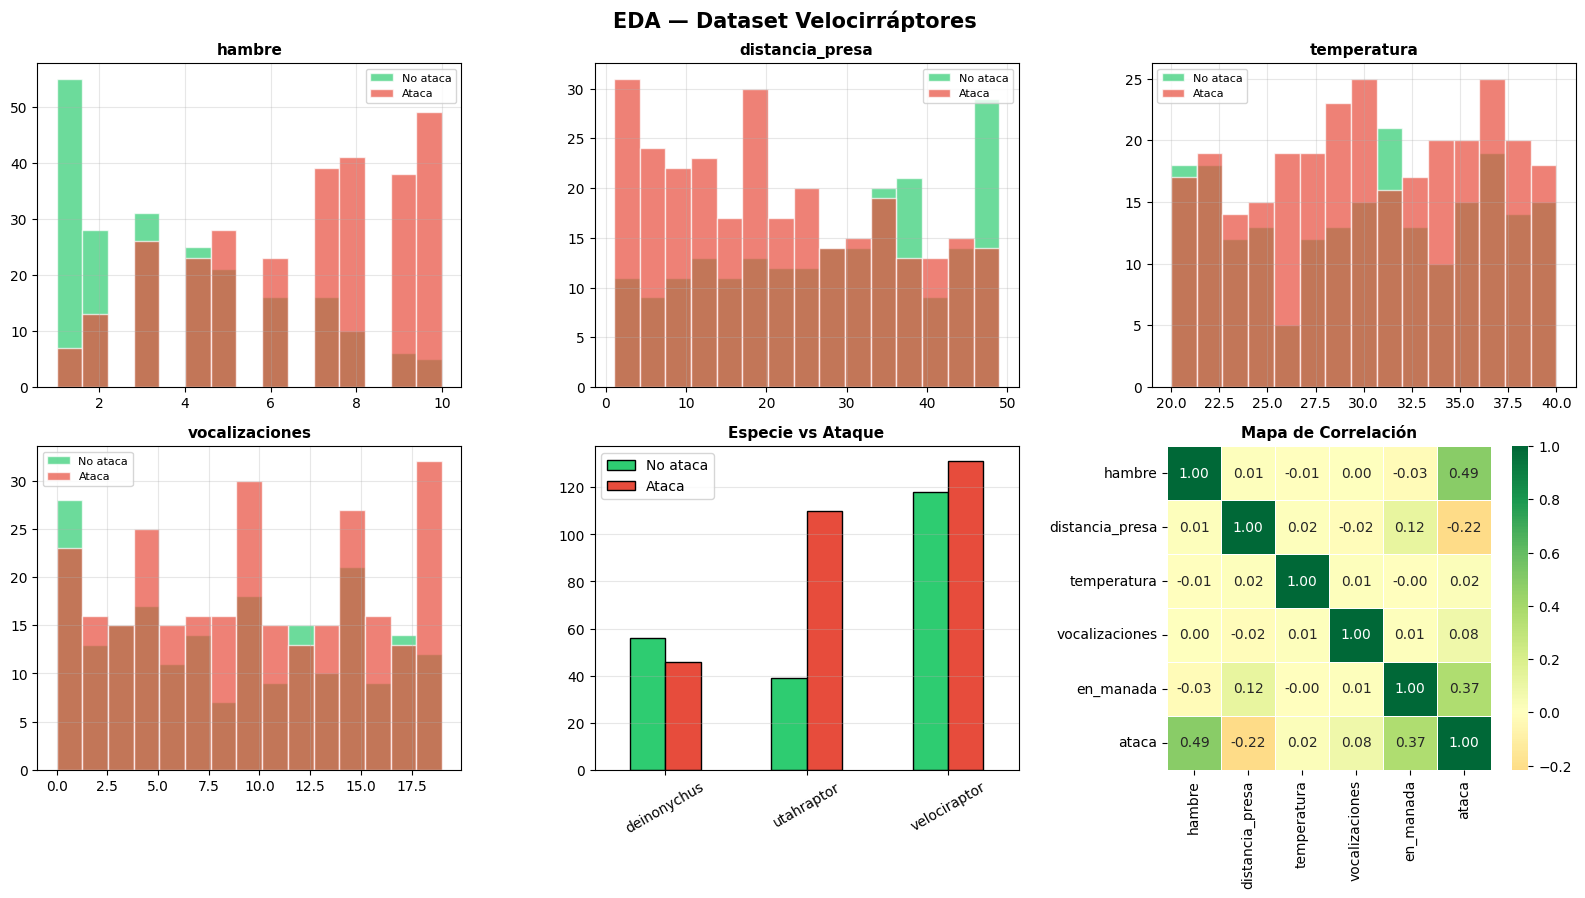

💡 Observaciones clave del EDA:
   • 'hambre' y 'distancia_presa' tienen mayor correlación con el ataque
   • 'especie' es categórica → necesita codificación (OneHotEncoder)
   • Variables numéricas en escalas distintas → necesitan StandardScaler


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Dataset Velocirráptores', fontsize=15, fontweight='bold')

colores = {0: '#2ecc71', 1: '#e74c3c'}
vars_num = ['hambre', 'distancia_presa', 'temperatura', 'vocalizaciones']

for i, var in enumerate(vars_num):
    ax = axes[i // 3][i % 3]
    for clase, color in colores.items():
        subset = df[df['ataca'] == clase][var]
        ax.hist(subset, alpha=0.7, color=color,
                label=f"{'Ataca' if clase==1 else 'No ataca'}",
                bins=15, edgecolor='white')
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Especie vs ataque
ax = axes[1][1]
especie_ataque = df.groupby(['especie', 'ataca']).size().unstack(fill_value=0)
especie_ataque.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
                    edgecolor='black', legend=True)
ax.set_title('Especie vs Ataque', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(['No ataca', 'Ataca'])
ax.grid(axis='y', alpha=0.3)

# Correlación
ax = axes[1][2]
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            center=0, square=True, linewidths=0.5)
ax.set_title('Mapa de Correlación', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 Observaciones clave del EDA:")
print("   • 'hambre' y 'distancia_presa' tienen mayor correlación con el ataque")
print("   • 'especie' es categórica → necesita codificación (OneHotEncoder)")
print("   • Variables numéricas en escalas distintas → necesitan StandardScaler")

## 🔧 PASO 3: ¿Qué es un Pipeline de ML y por qué es crítico?

### El problema sin Pipeline

Imagina que para predecir si un raptor ataca, haces esto:


### ❌ FORMA INCORRECTA (sin pipeline)
```
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)        # Escalas TODO el dataset
X_train, X_test = train_test_split(X_scaled, ...)  # Luego divides
modelo.fit(X_train, y_train)
modelo.predict(X_test)
```

¿Cuál es el problema? Que el scaler **vio los datos de test** al hacer `fit_transform(X)` completo.
Esto se llama **Data Leakage** y lo veremos en detalle en el Paso 4.

### ✅ FORMA CORRECTA (con pipeline)

Un **Pipeline** encadena transformaciones y modelos de forma que:
1. El preprocesamiento se aprende **solo** con datos de entrenamiento
2. Se aplica automáticamente a datos nuevos en producción
3. Todo el sistema viaja como **un único objeto** serializable

 🦖 **Metáfora**: El pipeline es el protocolo de InGen para manejar raptores.
    Sin protocolo, cada científico hace lo suyo y el sistema falla.
    Con protocolo estandarizado, cualquier técnico puede operar el sistema.

---
## ⚠️ PASO 4: Data Leakage — El error más peligroso en ML

El **Data Leakage** ocurre cuando información de los datos de test
"se filtra" al proceso de entrenamiento, dando resultados artificialmente buenos.

### Tipos de leakage

| Tipo | Ejemplo | Consecuencia |
|---|---|---|
| **Temporal** | Usar datos futuros para predecir el pasado | El modelo nunca funciona en producción |
| **Preprocesamiento** | Escalar antes de hacer train/test split | Métricas infladas artificialmente |
| **Target leakage** | Usar features que "conocen" el target | Accuracy perfecto pero inútil |

Vamos a **demostrar** el efecto del leakage con los datos de los raptores:

In [6]:
# Preparamos datos básicos (solo columnas numéricas)
X_num = df[['hambre', 'distancia_presa', 'temperatura', 'vocalizaciones', 'en_manada']].copy()
y = df['ataca'].copy()

print("🔬 EXPERIMENTO: Demostración de Data Leakage")
print("=" * 55)

# ──────────────────────────────────────────────────────────────
# ❌ FORMA INCORRECTA: Escalar ANTES de dividir
# ──────────────────────────────────────────────────────────────
scaler_erroneo= StandardScaler()
X_leaky = scaler_erroneo.fit_transform(X_num)  # ← usa TODO el dataset (incluye test!)

X_train_erroneo, X_test_erroneo, y_train, y_test = train_test_split(
    X_leaky, y, test_size=0.2, random_state=SEED, stratify=y
)

modelo_erroneo = DecisionTreeClassifier(max_depth=4, random_state=SEED)
modelo_erroneo.fit(X_train_erroneo, y_train)
acc_erroneo = accuracy_score(y_test, modelo_erroneo.predict(X_test_erroneo))

# ──────────────────────────────────────────────────────────────
# ✅ FORMA CORRECTA: Dividir ANTES de escalar
# ──────────────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler_correcto = StandardScaler()
X_train_scaled = scaler_correcto.fit_transform(X_train_raw)  # ← solo train
X_test_scaled  = scaler_correcto.transform(X_test_raw)       # ← aplica sin re-ajustar

modelo_correcto = DecisionTreeClassifier(max_depth=4, random_state=SEED)
modelo_correcto.fit(X_train_scaled, y_train)
acc_correcto = accuracy_score(y_test, modelo_correcto.predict(X_test_scaled))

# ──────────────────────────────────────────────────────────────
# Comparación de resultados
# ──────────────────────────────────────────────────────────────
diferencia = abs(acc_erroneo - acc_correcto) * 100

print(f"\n  ❌ Con Data Leakage (incorrecto): {acc_erroneo*100:.2f}%")
print(f"  ✅ Sin Data Leakage (correcto):   {acc_correct*100:.2f}%")
print(f"  📊 Diferencia artificial:         {diferencia:.2f} puntos porcentuales")
print()
print("💡 En este dataset sintético no se aprecia diferencia")
print("   en datos reales el leakage puede dar 95% de accuracy en lab")
print("   y caer a 60% en producción. Es el error más costoso en ML.")
print()
print("🛡️  LA SOLUCIÓN DEFINITIVA: usar un Pipeline de scikit-learn")
print("   El pipeline garantiza que el fit() solo ocurre en datos de train.")

🔬 EXPERIMENTO: Demostración de Data Leakage

  ❌ Con Data Leakage (incorrecto): 77.00%


NameError: name 'acc_correct' is not defined

---
## 🏗️ PASO 5: Construir el Pipeline con scikit-learn

Ahora construimos el pipeline completo que:
- Trata **columnas numéricas** con `StandardScaler`
- Trata **columnas categóricas** con `OneHotEncoder`
- Combina ambas transformaciones con `ColumnTransformer`
- Encadena todo con el modelo usando `Pipeline`

### División train/test — La primera y única vez

In [ ]:
# Definimos las features y el target
FEATURES_NUM = ['hambre', 'distancia_presa', 'temperatura', 'vocalizaciones']
FEATURES_BIN = ['en_manada']          # Binaria: no necesita escalar ni encode
FEATURES_CAT = ['especie']            # Categórica: necesita OneHotEncoder
TARGET = 'ataca'

X = df[FEATURES_NUM + FEATURES_BIN + FEATURES_CAT]
y = df[TARGET]

# ─── División train/test PRIMERO ────────────────────────────────────────────
# Esto es lo primero que hacemos. El test set queda "en cuarentena"
# y no lo tocamos hasta la evaluación final del Paso 8.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y           # Mantiene proporción de clases
)

print("✂️  DIVISIÓN TRAIN / TEST")
print("=" * 40)
print(f"  🏋️  Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  🔒  Test (cuarentena): {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("  Proporciones de la clase objetivo:")
print(f"    Train → {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"    Test  → {y_test.value_counts(normalize=True).round(3).to_dict()}")
print()
print("⚠️  El test set NO se toca hasta el Paso 8. ¡Es el examen final!")

✂️  DIVISIÓN TRAIN / TEST
  🏋️  Entrenamiento: 400 muestras (80%)
  🔒  Test (cuarentena): 100 muestras (20%)

  Proporciones de la clase objetivo:
    Train → {1: 0.575, 0: 0.425}
    Test  → {1: 0.57, 0: 0.43}

⚠️  El test set NO se toca hasta el Paso 8. ¡Es el examen final!


In [ ]:
# ─── 1. Preprocesador con ColumnTransformer ──────────────────────────────────
# ColumnTransformer aplica diferentes transformaciones a diferentes columnas

preprocesador = ColumnTransformer(
    transformers=[
        # (nombre, transformador, columnas)
        ('num', StandardScaler(), FEATURES_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
        # Las binarias las pasamos sin transformar (passthrough)
        ('bin', 'passthrough', FEATURES_BIN)
    ]
)

# ─── 2. Pipeline completo ────────────────────────────────────────────────────
# Pipeline encadena steps. El nombre de cada step puede usarse en GridSearchCV

pipeline = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(n_estimators=100, random_state=SEED))
])

print("🔧 PIPELINE CONSTRUIDO")
print("=" * 50)
print("💡 Cómo acceder a los parámetros del pipeline:")
print("   pipeline.get_params().keys()  → todos los parámetros")
print("   Notación: 'nombre_step__parametro' (doble guión bajo)")
print()
# Mostramos algunos parámetros clave
params_clave = {k: v for k, v in pipeline.get_params().items()
               if k in ['modelo__n_estimators', 'modelo__max_depth',
                        'preprocesador__num__with_std']}
print("   Parámetros clave actuales:")
for k, v in params_clave.items():
    print(f"   • {k}: {v}")

🔧 PIPELINE CONSTRUIDO
💡 Cómo acceder a los parámetros del pipeline:
   pipeline.get_params().keys()  → todos los parámetros
   Notación: 'nombre_step__parametro' (doble guión bajo)

   Parámetros clave actuales:
   • preprocesador__num__with_std: True
   • modelo__max_depth: None
   • modelo__n_estimators: 100


---
## 🔁 PASO 6: Validación Cruzada Robusta

Un único train/test split puede ser engañoso — depende de qué datos
cayeron en cada parte. La **validación cruzada** (cross-validation)
evalúa el modelo en **múltiples particiones** para obtener una estimación
más fiable del rendimiento real.

```
Datos de entrenamiento divididos en K pliegues (folds):

Fold 1: [████ TRAIN ████████████] [VAL]
Fold 2: [████ TRAIN ████] [VAL] [TRAIN ████]
Fold 3: [████ TRAIN ] [VAL] [████████ TRAIN]
Fold 4: [VAL] [████████████ TRAIN ████████]
         ↑
  Cada fold usa una porción diferente como validación
  → Promediamos los K resultados para una estimación robusta
```

> 🦖 **Ventaja clave**: el Pipeline garantiza que el preprocesamiento
> se re-ajusta en cada fold solo con los datos de entrenamiento de ese fold.

In [ ]:
# ─── StratifiedKFold: preserva la proporción de clases en cada fold ──────────
cv_strategy = StratifiedKFold(
    n_splits=5,         # 5 pliegues → 80% train, 20% val en cada fold
    shuffle=True,
    random_state=SEED
)

# ─── Validación cruzada ───────────────────────────────────────────────────────
# Importante: pasamos el PIPELINE completo, no el modelo solo.
# Así el preprocesamiento también se valida correctamente en cada fold.
print("🔁 Ejecutando validación cruzada con 5 folds...")
print("   (Esto puede tardar unos segundos)")
print()

cv_scores = cross_val_score(
    pipeline,           # Pipeline completo
    X_train, y_train,   # Solo datos de entrenamiento
    cv=cv_strategy,
    scoring='f1',       # F1 para datasets ligeramente desbalanceados
    n_jobs=-1           # Usar todos los cores disponibles
)

print("📊 RESULTADOS DE VALIDACIÓN CRUZADA (F1-Score)")
print("=" * 50)
for i, score in enumerate(cv_scores, 1):
    barra = '█' * int(score * 20)
    print(f"  Fold {i}: {barra:<20} {score:.4f}")
print("-" * 50)
print(f"  Media:       {cv_scores.mean():.4f}")
print(f"  Desv. Est.:  {cv_scores.std():.4f}  ← varianza del modelo")
print(f"  Intervalo:   [{cv_scores.mean()-cv_scores.std():.4f}, "
      f"{cv_scores.mean()+cv_scores.std():.4f}]")
print()
print("💡 Una desviación estándar baja indica un modelo ESTABLE.")
print("   Si los folds varían mucho → el modelo es inestable → problema.")

🔁 Ejecutando validación cruzada con 5 folds...
   (Esto puede tardar unos segundos)

📊 RESULTADOS DE VALIDACIÓN CRUZADA (F1-Score)
  Fold 1: ████████████████     0.8485
  Fold 2: ████████████████     0.8000
  Fold 3: ████████████████     0.8387
  Fold 4: ████████████████     0.8352
  Fold 5: ████████████████     0.8163
--------------------------------------------------
  Media:       0.8277
  Desv. Est.:  0.0174  ← varianza del modelo
  Intervalo:   [0.8104, 0.8451]

💡 Una desviación estándar baja indica un modelo ESTABLE.
   Si los folds varían mucho → el modelo es inestable → problema.


---
## ⚙️ PASO 7: GridSearchCV integrado en el Pipeline

Ahora optimizamos los hiperparámetros del modelo usando `GridSearchCV`.

**La clave**: al hacer GridSearch sobre el Pipeline completo, cada combinación
de hiperparámetros se evalúa con validación cruzada **sin leakage**.

La notación de parámetros sigue el patrón: `nombre_step__parametro`

In [ ]:
# ─── Grid de hiperparámetros ──────────────────────────────────────────────────
# Notación: 'nombre_step__parametro' (doble guión bajo)
param_grid = {
    'modelo__n_estimators': [50, 100, 200],
    'modelo__max_depth':    [3, 5, None],
    'modelo__min_samples_split': [2, 5]
}

print("⚙️  GRID DE BÚSQUEDA:")
total_combinaciones = 1
for k, v in param_grid.items():
    print(f"   {k}: {v}")
    total_combinaciones *= len(v)
print(f"\n   Total combinaciones: {total_combinaciones}")
print(f"   Con 5-fold CV: {total_combinaciones * 5} ajustes de modelo")
print()

# ─── GridSearchCV sobre el Pipeline completo ─────────────────────────────────
grid_search = GridSearchCV(
    pipeline,           # El pipeline COMPLETO (no solo el modelo)
    param_grid,
    cv=cv_strategy,     # Misma estrategia de CV
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True   # Para detectar overfitting
)

print("🔍 Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)

print()
print("✅ BÚSQUEDA COMPLETADA")
print("=" * 50)
print(f"  🏆 Mejores hiperparámetros encontrados:")
for k, v in grid_search.best_params_.items():
    print(f"     {k}: {v}")
print(f"\n  🎯 Mejor F1-Score (CV): {grid_search.best_score_:.4f}")

⚙️  GRID DE BÚSQUEDA:
   modelo__n_estimators: [50, 100, 200]
   modelo__max_depth: [3, 5, None]
   modelo__min_samples_split: [2, 5]

   Total combinaciones: 18
   Con 5-fold CV: 90 ajustes de modelo

🔍 Iniciando búsqueda de hiperparámetros...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ BÚSQUEDA COMPLETADA
  🏆 Mejores hiperparámetros encontrados:
     modelo__max_depth: 5
     modelo__min_samples_split: 2
     modelo__n_estimators: 200

  🎯 Mejor F1-Score (CV): 0.8447


In [ ]:
# Análisis de resultados del GridSearch
resultados_cv = pd.DataFrame(grid_search.cv_results_)

# Ordenamos por score
top_5 = (resultados_cv
         .sort_values('mean_test_score', ascending=False)
         .head(5)[['params', 'mean_test_score', 'std_test_score',
                   'mean_train_score', 'rank_test_score']]
         .rename(columns={
             'mean_test_score': 'F1_val (media)',
             'std_test_score':  'F1_val (std)',
             'mean_train_score': 'F1_train (media)',
             'rank_test_score': 'Ranking'
         })
)

print("📊 TOP 5 COMBINACIONES DE HIPERPARÁMETROS")
print(top_5.to_string(index=False))
print()
print("💡 Detectar Overfitting:")
print("   Si F1_train >> F1_val → el modelo memoriza en lugar de generalizar")
print("   Busca combinaciones donde train ≈ val (modelo equilibrado)")

# Accedemos al mejor pipeline ya ajustado
mejor_pipeline = grid_search.best_estimator_
print()
print("✅ 'mejor_pipeline' contiene el pipeline completo con los mejores parámetros")

📊 TOP 5 COMBINACIONES DE HIPERPARÁMETROS
                                                                                  params  F1_val (media)  F1_val (std)  F1_train (media)  Ranking
   {'modelo__max_depth': 5, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}        0.844705      0.021644          0.952335        1
   {'modelo__max_depth': 5, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}        0.844339      0.022479          0.948004        2
{'modelo__max_depth': None, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 100}        0.843797      0.030096          0.984835        3
{'modelo__max_depth': None, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}        0.843557      0.027419          0.984850        4
   {'modelo__max_depth': 5, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 100}        0.842156      0.027601          0.944516        5

💡 Detectar Overfitting:
   Si F1_train >> F1_val → el modelo memoriza en lugar de 

---
## 📊 PASO 8: Evaluación Final — El Examen Real

Ahora, por primera vez, usamos el **test set**.

> ⚠️ **Regla de oro**: el test set se usa **una sola vez**, al final.
> Si lo usas para ajustar el modelo, pierde su propósito.

In [ ]:
# Predicciones sobre el conjunto de test (primera y única vez)
y_pred = mejor_pipeline.predict(X_test)
y_prob = mejor_pipeline.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("🔒 EVALUACIÓN FINAL EN TEST SET")
print("=" * 55)
print(f"  🎯 Accuracy:   {acc*100:.2f}%")
print(f"  📊 F1-Score:   {f1:.4f}")
print(f"  📈 CV F1:      {grid_search.best_score_:.4f}  ← estimación durante desarrollo")
print()

diferencia_cv_test = abs(grid_search.best_score_ - f1)
if diferencia_cv_test < 0.03:
    print("✅ Diferencia CV↔Test pequeña: el modelo generaliza bien")
else:
    print(f"⚠️ Diferencia CV↔Test de {diferencia_cv_test:.3f}: posible sobreajuste")

print()
print("📋 REPORTE COMPLETO:")
print(classification_report(y_test, y_pred, target_names=['No ataca', 'Ataca']))

🔒 EVALUACIÓN FINAL EN TEST SET
  🎯 Accuracy:   79.00%
  📊 F1-Score:   0.8205
  📈 CV F1:      0.8447  ← estimación durante desarrollo

✅ Diferencia CV↔Test pequeña: el modelo generaliza bien

📋 REPORTE COMPLETO:
              precision    recall  f1-score   support

    No ataca       0.78      0.72      0.75        43
       Ataca       0.80      0.84      0.82        57

    accuracy                           0.79       100
   macro avg       0.79      0.78      0.78       100
weighted avg       0.79      0.79      0.79       100



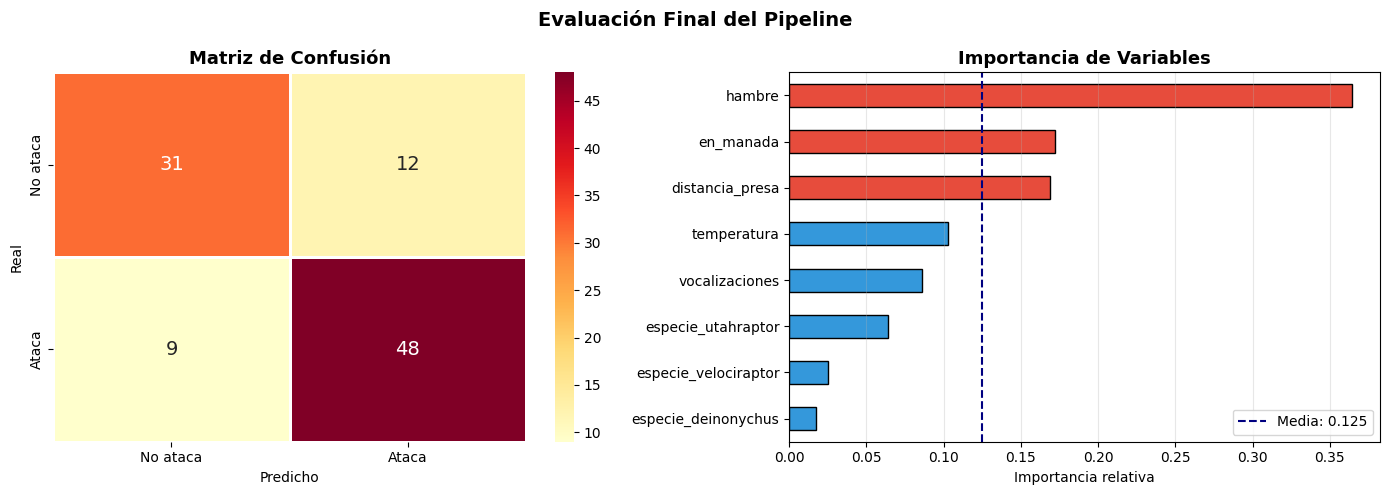


🥇 Variable más importante: hambre (0.364)


In [ ]:
# Visualización de la evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación Final del Pipeline', fontsize=14, fontweight='bold')

# Matriz de confusión
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['No ataca', 'Ataca'],
            yticklabels=['No ataca', 'Ataca'],
            ax=ax1, linewidths=1, annot_kws={'size': 14})
ax1.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
ax1.set_ylabel('Real')
ax1.set_xlabel('Predicho')

# Importancia de variables del Random Forest
ax2 = axes[1]
rf_model = mejor_pipeline.named_steps['modelo']
preprocessor = mejor_pipeline.named_steps['preprocesador']

# Reconstruimos los nombres de features tras el preprocesamiento
nombres_num = FEATURES_NUM
nombres_cat = list(preprocessor.named_transformers_['cat'].get_feature_names_out(FEATURES_CAT))
nombres_bin = FEATURES_BIN
nombres_features = nombres_num + nombres_cat + nombres_bin

importancias = pd.Series(rf_model.feature_importances_, index=nombres_features)
importancias_sorted = importancias.sort_values(ascending=True)

colores_imp = ['#e74c3c' if imp > importancias.mean() else '#3498db'
               for imp in importancias_sorted]
importancias_sorted.plot(kind='barh', ax=ax2, color=colores_imp, edgecolor='black')
ax2.axvline(importancias.mean(), color='navy', linestyle='--', linewidth=1.5,
             label=f'Media: {importancias.mean():.3f}')
ax2.set_title('Importancia de Variables', fontsize=13, fontweight='bold')
ax2.set_xlabel('Importancia relativa')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🥇 Variable más importante: {importancias.idxmax()} ({importancias.max():.3f})")

---
## 💾 PASO 9: Serialización y Versionado de Modelos

Un pipeline en memoria desaparece cuando cierras el notebook.
Para **producción** necesitamos:

1. **Serializar** (guardar) el pipeline completo en disco
2. **Versionar** los modelos con metadatos (fecha, métricas, parámetros)
3. **Cargar** el modelo para usarlo en producción

> 🦖 Es como el protocolo de almacenamiento de ADN de InGen:
> sin una versión preservada correctamente, no puedes recrear el raptor.

In [ ]:
import datetime

# ─── 1. Crear directorio de modelos ──────────────────────────────────────────
os.makedirs('modelos', exist_ok=True)

# ─── 2. Nombre con versión y fecha ───────────────────────────────────────────
fecha = datetime.datetime.now().strftime('%Y%m%d')
version = 'v1.0'
nombre_modelo = f'modelos/raptor_pipeline_{version}_{fecha}.joblib'

# ─── 3. Guardar el pipeline completo ─────────────────────────────────────────
# joblib es más eficiente que pickle para arrays numpy grandes
joblib.dump(mejor_pipeline, nombre_modelo)

# ─── 4. Guardar metadatos del modelo ─────────────────────────────────────────
# Los metadatos documentan el contexto del modelo (esencial en producción)
metadatos = {
    'version': version,
    'fecha_entrenamiento': fecha,
    'modelo_tipo': type(rf_model).__name__,
    'mejores_hiperparametros': grid_search.best_params_,
    'metricas_cv': {
        'f1_media': round(grid_search.best_score_, 4),
        'f1_std':   round(cv_scores.std(), 4)
    },
    'metricas_test': {
        'accuracy': round(acc, 4),
        'f1_score': round(f1, 4)
    },
    'features': {
        'numericas': FEATURES_NUM,
        'categoricas': FEATURES_CAT,
        'binarias': FEATURES_BIN
    },
    'n_train': len(X_train),
    'n_test': len(X_test),
    'seed': SEED
}

nombre_meta = nombre_modelo.replace('.joblib', '_metadata.json')
with open(nombre_meta, 'w') as f:
    json.dump(metadatos, f, indent=2)

# Verificar tamaño del archivo guardado
size_kb = os.path.getsize(nombre_modelo) / 1024

print("💾 SERIALIZACIÓN DEL PIPELINE")
print("=" * 50)
print(f"  📦 Modelo guardado:    {nombre_modelo}")
print(f"  📄 Metadatos:          {nombre_meta}")
print(f"  📏 Tamaño del modelo:  {size_kb:.1f} KB")
print()
print("📋 Metadatos guardados:")
print(json.dumps(metadatos, indent=2))

💾 SERIALIZACIÓN DEL PIPELINE
  📦 Modelo guardado:    modelos/raptor_pipeline_v1.0_20260512.joblib
  📄 Metadatos:          modelos/raptor_pipeline_v1.0_20260512_metadata.json
  📏 Tamaño del modelo:  838.0 KB

📋 Metadatos guardados:
{
  "version": "v1.0",
  "fecha_entrenamiento": "20260512",
  "modelo_tipo": "RandomForestClassifier",
  "mejores_hiperparametros": {
    "modelo__max_depth": 5,
    "modelo__min_samples_split": 2,
    "modelo__n_estimators": 200
  },
  "metricas_cv": {
    "f1_media": 0.8447,
    "f1_std": 0.0174
  },
  "metricas_test": {
    "accuracy": 0.79,
    "f1_score": 0.8205
  },
  "features": {
    "numericas": [
      "hambre",
      "distancia_presa",
      "temperatura",
      "vocalizaciones"
    ],
    "categoricas": [
      "especie"
    ],
    "binarias": [
      "en_manada"
    ]
  },
  "n_train": 400,
  "n_test": 100,
  "seed": 42
}


In [ ]:
# ─── 5. Verificar que el modelo cargado funciona igual ───────────────────────
print("🔄 VERIFICACIÓN: Cargar y usar el modelo serializado")
print("=" * 55)

# Cargamos el modelo desde disco (simulando producción)
pipeline_cargado = joblib.load(nombre_modelo)

# Verificamos que las predicciones son idénticas
y_pred_cargado = pipeline_cargado.predict(X_test)
predicciones_identicas = np.array_equal(y_pred, y_pred_cargado)

print(f"  Modelo original cargado:  ✅")
print(f"  Predicciones idénticas:   {'✅ SÍ' if predicciones_identicas else '❌ NO'}")
print()
print("✅ El pipeline se serializa y carga correctamente.")
print("   Incluye el preprocesador + modelo en un único objeto.")
print()
print("💡 En producción, simplemente harías:")
print("   pipeline = joblib.load('modelos/raptor_pipeline_v1.0_YYYYMMDD.joblib')")
print("   prediccion = pipeline.predict(nuevos_datos)")

🔄 VERIFICACIÓN: Cargar y usar el modelo serializado
  Modelo original cargado:  ✅
  Predicciones idénticas:   ✅ SÍ

✅ El pipeline se serializa y carga correctamente.
   Incluye el preprocesador + modelo en un único objeto.

💡 En producción, simplemente harías:
   pipeline = joblib.load('modelos/raptor_pipeline_v1.0_YYYYMMDD.joblib')
   prediccion = pipeline.predict(nuevos_datos)


---
## 🚀 PASO 10: Predicción en Producción

Simulamos el uso del sistema en producción.
Los datos llegan **sin transformar** (datos brutos del sensor).
El pipeline se encarga de todo automáticamente.

In [ ]:
# Datos brutos llegando del sistema de sensores de InGen
# Exactamente el mismo formato que en entrenamiento
alertas_raptor = pd.DataFrame({
    'hambre':          [9,   2,   5,   8,   1,   7],
    'distancia_presa': [3,   40,  20,  5,   50,  15],
    'temperatura':     [35,  22,  28,  33,  20,  30],
    'vocalizaciones':  [15,  2,   8,   18,  1,   10],
    'en_manada':       [1,   0,   0,   1,   0,   1],
    'especie':         ['utahraptor', 'deinonychus', 'velociraptor',
                        'utahraptor', 'deinonychus', 'velociraptor']
})

escenarios = [
    "Raptor muy hambriento, cerca, en manada, utahraptor",
    "Raptor saciado, lejos, solo, deinonychus",
    "Hambre media, distancia media, velociraptor",
    "Hambriento, muy cerca, en manada, utahraptor",
    "Sin hambre, muy lejos, solo, deinonychus",
    "Hambriento, distancia media, en manada, velociraptor"
]

# ─── El pipeline procesa datos brutos directamente ───────────────────────────
# No necesitamos escalar manualmente ni codificar la especie
# ¡El pipeline lo hace todo!
predicciones = pipeline_cargado.predict(alertas_raptor)
probabilidades = pipeline_cargado.predict_proba(alertas_raptor)

print("🦖 SISTEMA InGen ML v2.0 — PREDICCIONES EN TIEMPO REAL")
print("=" * 65)

for i, (esc, pred, prob) in enumerate(zip(escenarios, predicciones, probabilidades)):
    resultado = "🚨 ATACA" if pred == 1 else "✅ No ataca"
    p_ataca = prob[1] * 100
    p_no_ataca = prob[0] * 100
    
    # Barra de probabilidad visual
    barra_riesgo = '█' * int(p_ataca / 5)
    
    
    print(f"\nCaso {i+1}: {esc}")
    print(f"  Predicción: {resultado}")

    print(f"  Riesgo:  {barra_riesgo}{p_ataca:.1f}% | Seguro: {p_no_ataca:.1f}%")

print()
print("=" * 65)
print("💡 El pipeline transforma automáticamente los datos brutos.")
print("   Mismo StandardScaler, mismo OneHotEncoder, mismo modelo.")
print("   Reproducibilidad garantizada en producción.")

🦖 SISTEMA InGen ML v2.0 — PREDICCIONES EN TIEMPO REAL

Caso 1: Raptor muy hambriento, cerca, en manada, utahraptor
  Predicción: 🚨 ATACA
  Riesgo:  ███████████████████96.7% | Seguro: 3.3%

Caso 2: Raptor saciado, lejos, solo, deinonychus
  Predicción: ✅ No ataca
  Riesgo:  ██12.9% | Seguro: 87.1%

Caso 3: Hambre media, distancia media, velociraptor
  Predicción: ✅ No ataca
  Riesgo:  ███████39.3% | Seguro: 60.7%

Caso 4: Hambriento, muy cerca, en manada, utahraptor
  Predicción: 🚨 ATACA
  Riesgo:  ███████████████████97.0% | Seguro: 3.0%

Caso 5: Sin hambre, muy lejos, solo, deinonychus
  Predicción: ✅ No ataca
  Riesgo:  ██12.3% | Seguro: 87.7%

Caso 6: Hambriento, distancia media, en manada, velociraptor
  Predicción: 🚨 ATACA
  Riesgo:  █████████████████86.1% | Seguro: 13.9%

💡 El pipeline transforma automáticamente los datos brutos.
   Mismo StandardScaler, mismo OneHotEncoder, mismo modelo.
   Reproducibilidad garantizada en producción.


---
## 🎉 ¡Enhorabuena! Has completado el Pipeline de ML de Producción

### Resumen de lo aprendido

| Concepto | ¿Qué es? | Por qué importa |
|---|---|---|
| **Pipeline** | Cadena de pasos encadenados | Reproducibilidad y escalabilidad |
| **ColumnTransformer** | Transformaciones por tipo de columna | Manejo de datos heterogéneos |
| **Data Leakage** | Filtración de info de test al entrenamiento | Métricas irreales en producción |
| **StratifiedKFold** | CV con proporciones de clase preservadas | Evaluación robusta en desbalanceo |
| **GridSearchCV + Pipeline** | Búsqueda de hiperparámetros sin leakage | Optimización correcta y eficiente |
| **joblib** | Serialización eficiente de modelos | Despliegue en producción |
| **Metadatos** | Registro del contexto del modelo | Reproducibilidad y mantenimiento |

### 🔑 Las 3 reglas de oro de un Pipeline en producción

1. **Divide primero, transforma después** → el test set nunca ve el `fit()`
2. **Todo dentro del Pipeline** → preprocessing + modelo como un único objeto
3. **Versiona y documenta** → guarda modelo + metadatos + métricas

---

### 🦖 Próximos pasos

- **Explora más modelos**: GradientBoosting, XGBoost, LightGBM
- **Añade Feature Engineering** dentro del pipeline con `FunctionTransformer`
- **Manejo de valores nulos** con `SimpleImputer` en el pipeline
- **Despliegue con FastAPI**: convierte el pipeline en una API REST
- **MLflow**: plataforma profesional para versionar experimentos de ML

---

> *"Sus científicos estaban tan preocupados por si podían hacerlo o no,
> que no se detuvieron a pensar si debían hacerlo."* — Dr. Ian Malcolm
>
> En ML también: un pipeline robusto no solo te dice **si puedes** predecir,
> sino **si debes** confiar en esa predicción en producción. 🌿